# Spotify App Reviews

## 3.1 Cleaning & Exploratory Data Analysis
This section will go through initial data loading, cleaning, and exploration

In [ ]:
#Import relevevant libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Define paths to repository & dataset (If not done so already, add shortcut to spotify_reviews.csv to your "MyDrive")
data_path = '/content/drive/MyDrive/spotify_reviews.csv'

#Load data set
data = pd.read_csv(data_path)

### 3.1.1 Data Overview

In [ ]:
# Display the shape and first few rows of the dataset
print(data.shape)
data.head()

(84165, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,437314fe-1b1d-4352-abea-12fec30fce58,Rajib Das,It's good,4,0,NaN,2024-05-09 16:28:13,NaN
1,4933ad2c-c70a-4a84-957d-d405439b2e0f,Mihaela Claudia Neagu,"I love this app so much, I've been using Spoti...",5,0,8.9.38.494,2024-05-09 16:27:18,8.9.38.494
2,1ab275fb-59bf-42c7-88ef-b85901f0445e,JONATHAN GRACIA,Perfect,5,0,8.9.36.616,2024-05-09 16:27:03,8.9.36.616
3,b38406eb-7b11-4ceb-a45c-d7f28fb5d382,Cam Rempel,Best all around music streaming app I have use...,5,0,8.9.38.494,2024-05-09 16:26:19,8.9.38.494
4,7be7999d-4cb6-47b9-8414-d7bdaa9df578,Your clowness (Her Clowness),Are y'all fr gatekeeping the play button on so...,1,0,8.9.38.494,2024-05-09 16:26:14,8.9.38.494


In [ ]:
# Display the column names and data types
print("\nColumn names and data types:")
print(data.dtypes)


Column names and data types:
reviewId                object
userName                object
content                 object
score                    int64
thumbsUpCount            int64
reviewCreatedVersion    object
at                      object
appVersion              object
dtype: object


### 3.1.2 Data Cleaning

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
reviewId                   0
userName                   4
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    5768
at                         0
appVersion              5768
dtype: int64


In [ ]:
# Calculate proportion of rows with missing values

# Calculate the total number of reviews
total_reviews = len(data)

# Calculate the number of reviews with at least one missing value
missing_reviews = data.isnull().any(axis=1).sum()

# Calculate the proportion of missing values
proportion_missing = missing_reviews / total_reviews

# Format the proportion as a percentage
percentage_missing = proportion_missing * 100

# Print the result
print(f"Out of {total_reviews:,} reviews, {missing_reviews:,} have missing values.")
print(f"This represents {percentage_missing:.2f}% of the data.")

Out of 84,165 reviews, 5,772 have missing values.
This represents 6.86% of the data.


In [ ]:
# Handle missing values
# Here we'll drop rows with missing content, since it only constitutes ~7% of the data set
data = data.dropna()
print(data.isnull().sum())

reviewId                0
userName                0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
appVersion              0
dtype: int64


In [ ]:
# Check for duplicates
print("\nNumber of duplicate rows:")
print(data.duplicated().sum())


Number of duplicate rows:
0


In [ ]:
# Verify the data types
print("\nData types before conversion:")
print(data.dtypes)


Data types before conversion:
reviewId                object
userName                object
content                 object
score                    int64
thumbsUpCount            int64
reviewCreatedVersion    object
at                      object
appVersion              object
dtype: object


In [ ]:
# Convert 'at' to datetime
data['at'] = pd.to_datetime(data['at'], errors='coerce')

In [ ]:
# Verify the conversion
print("\nData types after conversion:")
print(data.dtypes)


Data types after conversion:
reviewId                        object
userName                        object
content                         object
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion            object
at                      datetime64[ns]
appVersion                      object
dtype: object


In [ ]:
total_reviews = len(data)
print(f"Total reviews after cleaning {total_reviews:,}")

Total reviews after cleaning 78,393


In [ ]:
"""
# Save the cleaned data (optional)
data.to_csv('/mnt/data/spotify_reviews_cleaned.csv', index=False)

print("\nData cleaning complete. Cleaned data saved as 'spotify_reviews_cleaned.csv'.")
"""

'\n# Save the cleaned data (optional)\ndata.to_csv(\'/mnt/data/spotify_reviews_cleaned.csv\', index=False)\n\nprint("\nData cleaning complete. Cleaned data saved as \'spotify_reviews_cleaned.csv\'.")\n'

### 3.1.3 Descriptive Statistics

In [ ]:
# View summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
print(data.describe())


Summary statistics for numerical columns:
              score  thumbsUpCount                             at
count  78393.000000   78393.000000                          78393
mean       2.464212      16.799599  2022-08-24 10:07:52.656742656
min        1.000000       0.000000            2018-09-12 08:43:37
25%        1.000000       0.000000            2021-03-25 15:02:10
50%        2.000000       1.000000            2023-06-26 14:14:28
75%        4.000000       5.000000            2024-02-21 13:38:14
max        5.000000    9781.000000            2024-05-09 16:27:18
std        1.514497     105.690499                            NaN


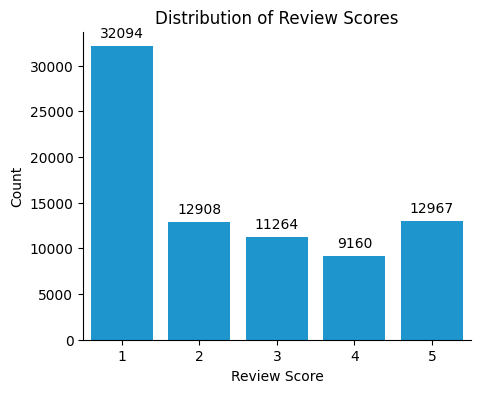

In [ ]:
# Explore the distribution of the review scores
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=data, x='score', color='#01A0EA')

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

# Remove the top and right spines (borders)
sns.despine(left=False, bottom=False)

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

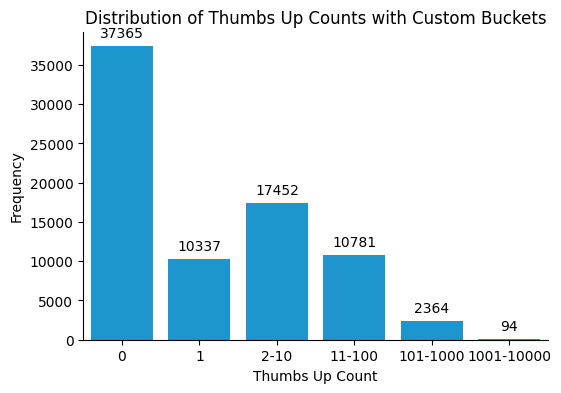

In [ ]:
# Define the bins and labels
bins = [-1, 0, 1, 10, 100, 1000, 10000]
labels = ['0', '1', '2-10', '11-100', '101-1000', '1001-10000']

# Create a new column for the binned data
data['thumbsUpBins'] = pd.cut(data['thumbsUpCount'], bins=bins, labels=labels, right=True)

# Plot the histogram for thumbs up counts with the specified buckets
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x='thumbsUpBins', color='#01A0EA')

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

# Remove the top and right spines (borders)
sns.despine(left=False, bottom=False)

plt.title('Distribution of Thumbs Up Counts with Custom Buckets')
plt.xlabel('Thumbs Up Count')
plt.ylabel('Frequency')
plt.show()

### 3.1.4 User Analysis

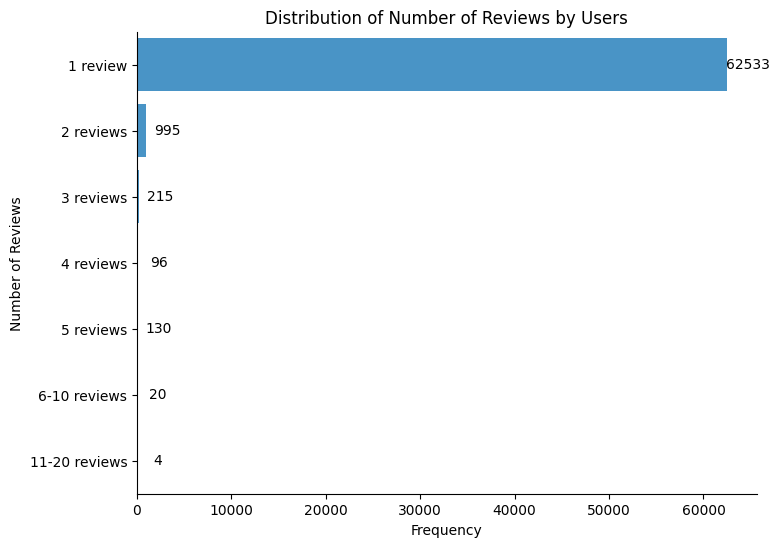

In [ ]:
# Analyze the distribution of reviews by user
user_review_counts = data['userName'].value_counts()

# Define custom bins and labels
bins = [1, 2, 3, 4, 5, 11, 21, user_review_counts.max()+1]
labels = ['1 review', '2 reviews', '3 reviews', '4 reviews', '5 reviews', '6-10 reviews', '11-20 reviews', '>20 reviews']

# Adjust labels to be one fewer than bins
labels = labels[:-1]

# Create a new column for the binned data
user_review_bins = pd.cut(user_review_counts, bins=bins, labels=labels, right=False, include_lowest=True)

# Plot the histogram for the custom bins
plt.figure(figsize=(8, 6))
ax = sns.countplot(y=user_review_bins, color='#3498db')

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_width(), '.0f'),
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='center', va='center',
                xytext=(15, 0),
                textcoords='offset points')

# Remove the top and right spines (borders)
sns.despine(left=False, bottom=False)

plt.title('Distribution of Number of Reviews by Users')
plt.xlabel('Frequency')
plt.ylabel('Number of Reviews')
plt.show()

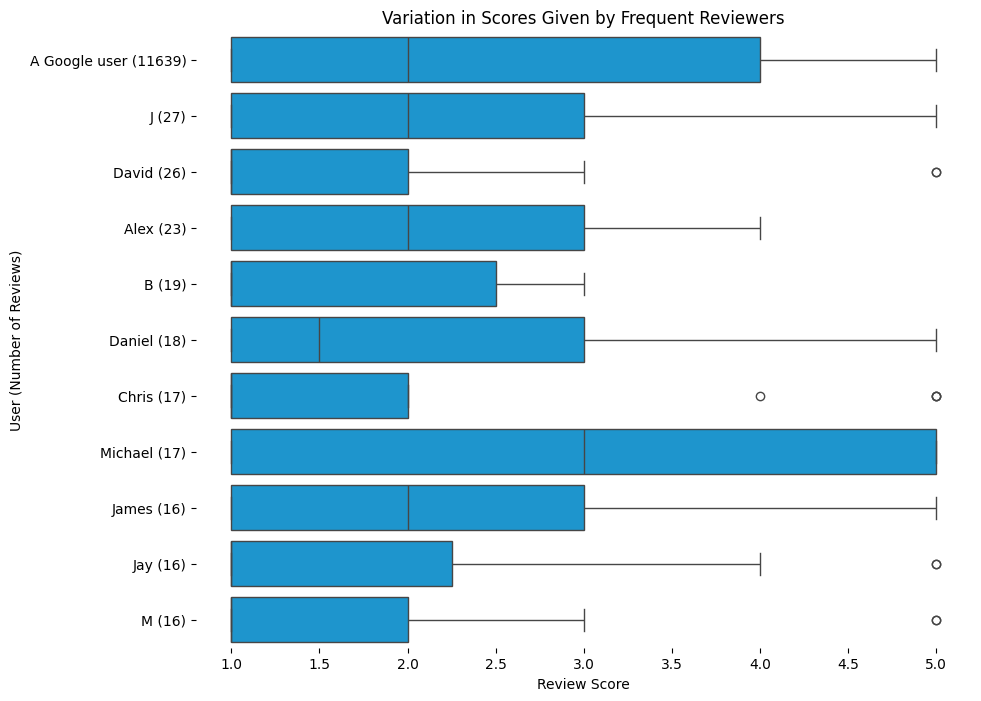

In [ ]:
# Analyze the distribution of reviews by user
user_review_counts = data['userName'].value_counts()

# Define frequent reviewers as those with more than 15 reviews
frequent_reviewers = user_review_counts[user_review_counts > 15].index
frequent_reviewer_data = data[data['userName'].isin(frequent_reviewers)]

# Create a new column combining user name and review count for display purposes
user_review_counts_df = user_review_counts.reset_index()
user_review_counts_df.columns = ['userName', 'reviewCount']

# Sort the frequent reviewers by the number of reviews in descending order
user_review_counts_df = user_review_counts_df[user_review_counts_df['userName'].isin(frequent_reviewers)]
user_review_counts_df = user_review_counts_df.sort_values(by='reviewCount', ascending=False)

# Merge the sorted review counts back to the frequent reviewer data
frequent_reviewer_data = frequent_reviewer_data.merge(user_review_counts_df, on='userName', how='left')
frequent_reviewer_data['user_display'] = frequent_reviewer_data['userName'] + ' (' + frequent_reviewer_data['reviewCount'].astype(str) + ')'

# Plot variation in scores given by frequent reviewers with horizontal bars
plt.figure(figsize=(10, 8))
ax = sns.boxplot(data=frequent_reviewer_data, y='user_display', x='score', order=user_review_counts_df['userName'] + ' (' + user_review_counts_df['reviewCount'].astype(str) + ')', color='#01A0EA')

# Remove the top and right spines (borders)
sns.despine(left=True, bottom=True)

plt.title('Variation in Scores Given by Frequent Reviewers')
plt.xlabel('Review Score')
plt.ylabel('User (Number of Reviews)')
plt.show()

### 3.1.5 Time-based Analysis

In [ ]:
# Exclude reviews given in the partial month of may 2024 (to not skew averages)
data = data[data['at'] < '2024-05-01']

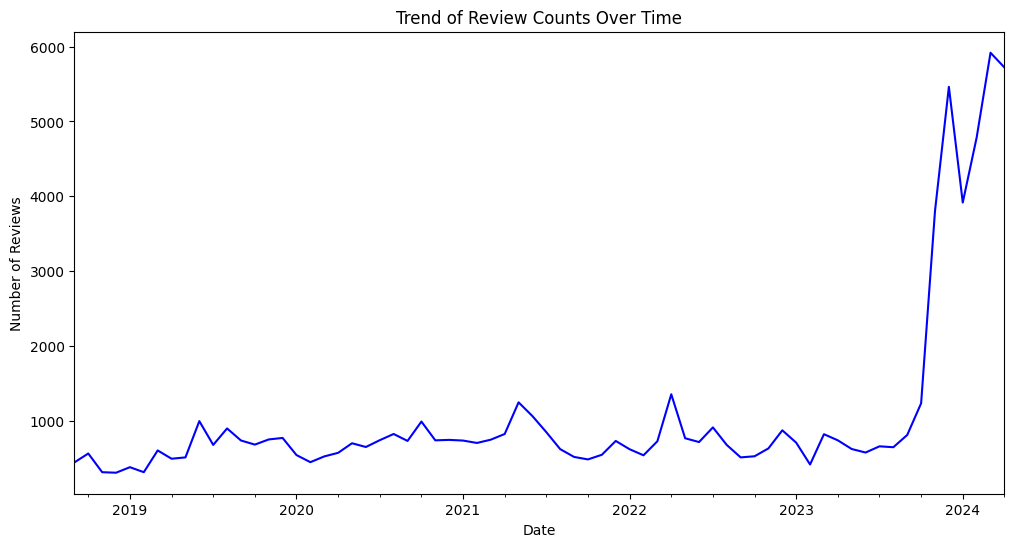

In [ ]:
# Analyze the trend of review counts over time
review_counts_over_time = data.set_index('at').resample('M').size()

plt.figure(figsize=(12, 6))
review_counts_over_time.plot(color='blue')
plt.title('Trend of Review Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(False)
plt.show()

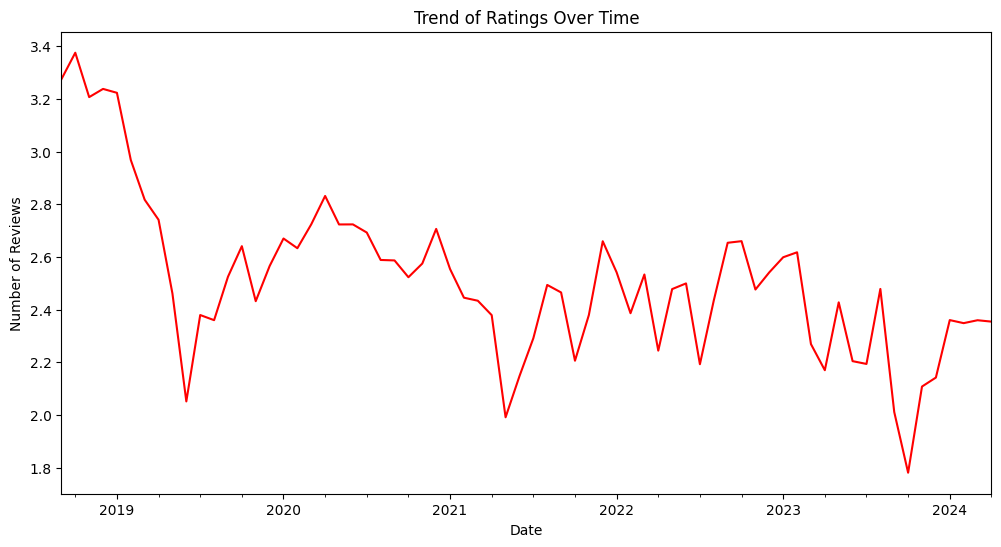

In [ ]:
# Analyze the ratings over time
average_score_over_time = data.set_index('at').resample('M')['score'].mean()

plt.figure(figsize=(12, 6))
average_score_over_time.plot(color='red')
plt.title('Trend of Ratings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(False)
plt.show()

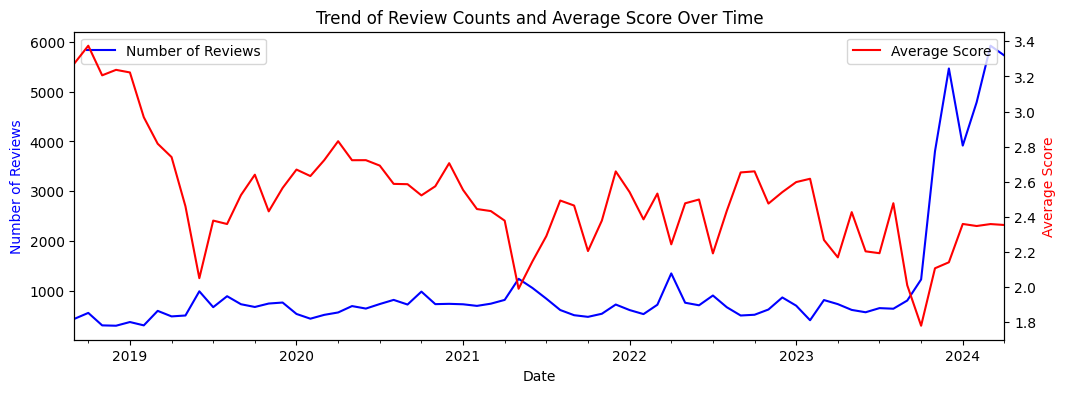

In [ ]:
# Analyze the trend of review counts and average score over time
review_counts_over_time = data.set_index('at').resample('M').size()
average_score_over_time = data.set_index('at').resample('M')['score'].mean()

plt.figure(figsize=(12, 4))
ax1 = review_counts_over_time.plot(color='blue', grid=False, label='Number of Reviews')
ax2 = ax1.twinx()
average_score_over_time.plot(ax=ax2, color='red', grid=False, label='Average Score')

ax1.set_title('Trend of Review Counts and Average Score Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Reviews', color='blue')
ax2.set_ylabel('Average Score', color='red')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

<ipython-input-24-9c2eefb6494a>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['majorAppVersion'] = new_data['appVersion'].apply(lambda x: '.'.join(x.split('.')[:3]))
<ipython-input-24-9c2eefb6494a>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['week'] = new_data['at'].dt.to_period('W').apply(lambda r: r.start_time)
<ipython-input-24-9c2eefb6494a>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

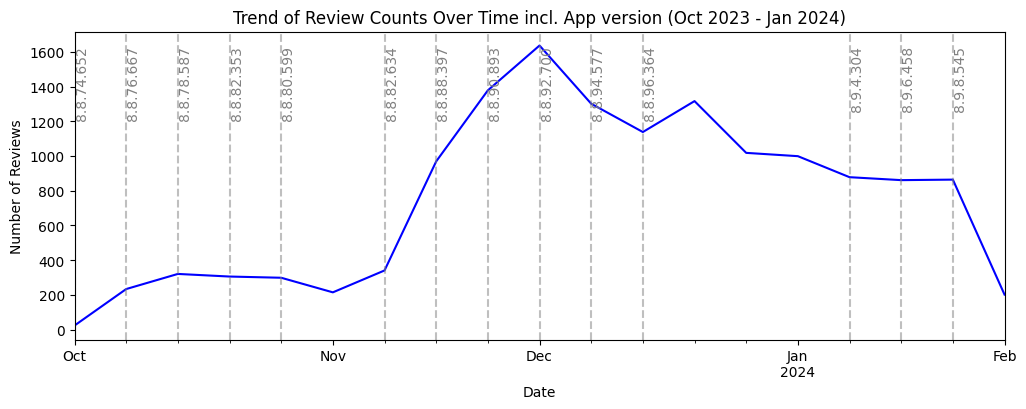

In [ ]:
#Zooming in on 2023-2024 and versions released
# Function to convert version strings to numerical tuples for comparison
def version_to_tuple(version):
    return tuple(map(int, (version.split('.'))))

# Load the cleaned new_dataset
new_data = pd.read_csv(data_path)

# Check for duplicate columns and remove them if necessary
new_data = new_data.loc[:, ~new_data.columns.duplicated()]

# Convert 'at' to datetime if not already done
new_data['at'] = pd.to_datetime(new_data['at'], errors='coerce')

# Filter for reviews from October 2023 to January 2024
start_date = pd.to_datetime('2023-10-01')
end_date = pd.to_datetime('2024-01-31')
new_data = new_data[(new_data['at'] >= start_date) & (new_data['at'] <= end_date)]

# Remove rows with missing app versions
new_data = new_data.dropna(subset=['appVersion'])

# Filter out versions lower than 8.4.70
new_data = new_data[new_data['appVersion'].apply(version_to_tuple) >= version_to_tuple('8.4.70')]

# Truncate app versions to keep only the first three segments
new_data['majorAppVersion'] = new_data['appVersion'].apply(lambda x: '.'.join(x.split('.')[:3]))

# Add a week column
new_data['week'] = new_data['at'].dt.to_period('W').apply(lambda r: r.start_time)

# Find the highest version for each week
new_data['version_tuple'] = new_data['appVersion'].apply(version_to_tuple)
weekly_max_version = new_data.groupby('week')['version_tuple'].max().reset_index()
weekly_max_version['maxAppVersion'] = weekly_max_version['version_tuple'].apply(lambda x: '.'.join(map(str, x)))

# Merge the highest version back to the main new_data
new_data = new_data.merge(weekly_max_version[['week', 'maxAppVersion']], on='week', how='left')

# Extract the earliest review date for each major app version (using weekly max version)
major_version_release_dates = new_data.groupby('maxAppVersion')['at'].min().reset_index()
major_version_release_dates.columns = ['maxAppVersion', 'releaseDate']

# Sort by release date
major_version_release_dates = major_version_release_dates.sort_values(by='releaseDate')

# Plot review counts over time on a weekly basis
review_counts_over_time = new_data.set_index('at').resample('W').size()

plt.figure(figsize=(12, 4))
ax = review_counts_over_time.plot(color='blue', grid=False, label='Number of Reviews')
ax.set_title('Trend of Review Counts Over Time incl. App version (Oct 2023 - Jan 2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Reviews')

# Overlay the major app version release dates
for i, row in major_version_release_dates.iterrows():
    ax.axvline(x=row['releaseDate'], color='grey', linestyle='--', alpha=0.5)
    ax.text(row['releaseDate'], max(review_counts_over_time), row['maxAppVersion'], rotation=90, verticalalignment='top', color='grey')

plt.show()

### 3.1.6 Text Data Analysis


Summary statistics for review length (characters):
count    72223.000000
mean       321.876369
std        129.029359
min         17.000000
25%        241.000000
50%        326.000000
75%        426.000000
max       2674.000000
Name: review_length, dtype: float64

Summary statistics for review word count:
count    72223.000000
mean        60.468770
std         24.573083
min          2.000000
25%         44.000000
50%         61.000000
75%         80.000000
max        474.000000
Name: review_word_count, dtype: float64


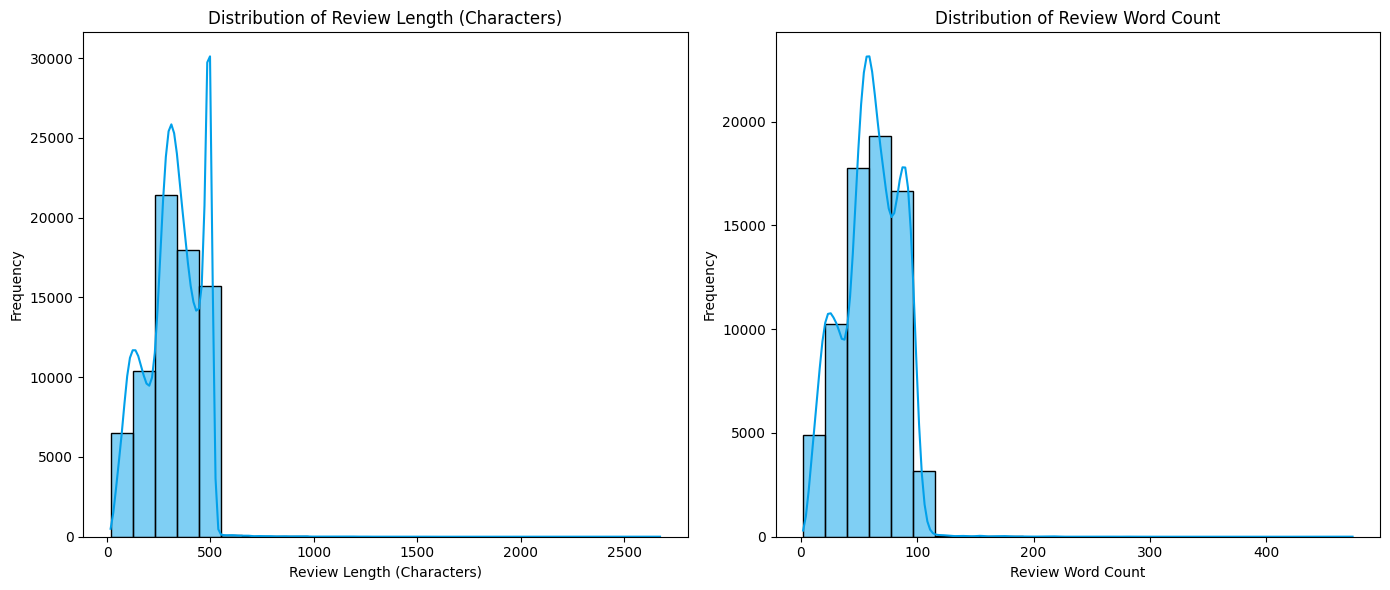

In [ ]:
# Calculate review length in terms of number of characters
data['review_length'] = data['content'].apply(len)

# Calculate review length in terms of number of words
data['review_word_count'] = data['content'].apply(lambda x: len(x.split()))

# Summary statistics for review length
print("\nSummary statistics for review length (characters):")
print(data['review_length'].describe())

print("\nSummary statistics for review word count:")
print(data['review_word_count'].describe())

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the distribution of review lengths
sns.histplot(data['review_length'], bins=25, kde=True, color='#01A0EA', ax=axes[0])
axes[0].set_title('Distribution of Review Length (Characters)')
axes[0].set_xlabel('Review Length (Characters)')
axes[0].set_ylabel('Frequency')

# Plot the distribution of review word counts
sns.histplot(data['review_word_count'], bins=25, kde=True, color='#01A0EA', ax=axes[1])
axes[1].set_title('Distribution of Review Word Count')
axes[1].set_xlabel('Review Word Count')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

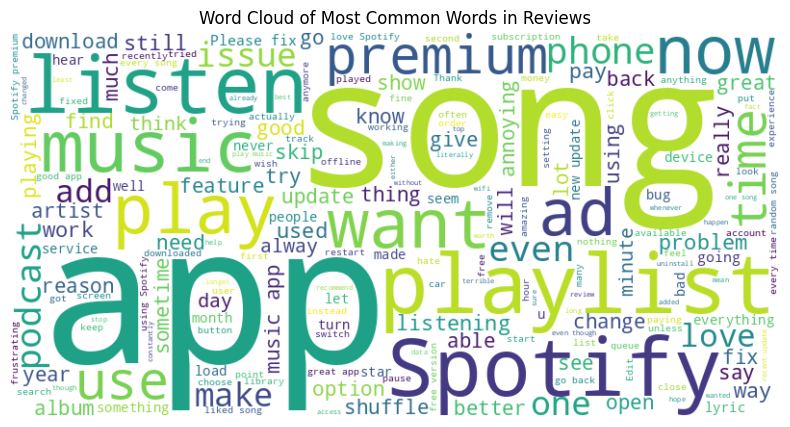

In [ ]:
#Word Frequency Analysis (2018-2024)
from collections import Counter
from wordcloud import WordCloud

# Join all the reviews into a single string
all_reviews = ' '.join(data['content'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_reviews)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Common Words in Reviews')
plt.show()

# Calculate the frequency of each word
word_freq = Counter(all_reviews.split())

# Convert the word frequency dictionary to a DataFrame
word_freq_df = pd.DataFrame(word_freq.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=a244c4177db8421d30b554e29162073c518ecf52b04b85203015a4bc53a97fc7
  Stored in directory: /root/.cache/pip/wheels/95/03/7d/59ea870c70ce4e5a370638b5462a7711ab78fba2f655d05106
Successfully built langdetect


In [ ]:
# Check Language of reviews
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

# Set seed for reproducibility
DetectorFactory.seed = 0

# Function to detect the language of a review
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

# Detect the language for each review
data['language'] = data['content'].apply(detect_language)

# Display the proportion of each language
language_counts = data['language'].value_counts(normalize=True)

# Print the language distribution
print("\nLanguage distribution in the dataset in %:")
print(language_counts*100)

KeyboardInterrupt: 

In [ ]:
#Investigate presence of Emojies
import re

# Function to extract emojis from text
def extract_emojis(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags
                           u"\U00002700-\U000027BF"  # Dingbats
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.findall(text)

# Extract emojis from each review
data['emojis'] = data['content'].apply(extract_emojis)

# Calculate the number of reviews including emojis
num_reviews_with_emojis = data[data['emojis'].str.len() > 0].shape[0]

# Calculate the percentage of reviews including emojis
percentage_reviews_with_emojis = (num_reviews_with_emojis / data.shape[0]) * 100

# Print the number and percentage of reviews including emojis
print(f"Number of reviews including emojis: {num_reviews_with_emojis}")
print(f"Percentage of reviews including emojis: {percentage_reviews_with_emojis:.2f}%")

# Display examples of reviews including emojis
reviews_with_emojis = data[data['emojis'].str.len() > 0][['content', 'emojis']]
print("\nExamples of reviews including emojis:")
reviews_with_emojis.head(5)  # Display the first 10 examples

Number of reviews including emojis: 4852
Percentage of reviews including emojis: 6.72%

Examples of reviews including emojis:


,content,emojis
1203,Free version don't have option to download the...,[😞]
1248,I've lowered my rating from 5 to 3 stars. I us...,[♂️]
1331,I've used spotify my entire life and always lo...,[🙏🙏🙏🙏🙏🙏🙏]
1422,There is no longer a setting for enabling Car ...,[💩]
1424,"Used to be great, now recently if I'm online m...",[🏼]


In [ ]:
#Analyze the Frequency of Emojis
from collections import Counter

# Flatten the list of emojis and count the frequency of each emoji
all_emojis = [emoji for sublist in data['emojis'] for emoji in sublist]
emoji_counts = Counter(all_emojis)

# Convert the emoji counts to a DataFrame
emoji_df = pd.DataFrame(emoji_counts.items(), columns=['emoji', 'count']).sort_values(by='count', ascending=False)

# Display the top 10 most common emojis
print("\nTop 10 most common emojis:")
print(emoji_df.head(10))


Top 10 most common emojis:
    emoji  count
31      😡    235
15      👍    205
24      😭    182
22      👎    172
13      🙄    164
17      😔    144
55     ❤️    143
5       😒    139
12      🙏    126
130     😊    112


## 3.2 Preprocessing V2

In [ ]:
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 2.7 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk import pos_tag
import re
import emoji

In [ ]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Load stopwords
stop_words = set(stopwords.words('english'))

# Initialize tokenizer and lemmatizer
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()

In [ ]:
# Function to preprocess text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove emojis or replace them with text
    # text = emoji.demojize(text, delimiters=(" ", " "))  # This replaces emojis with text descriptions

    # Tokenize and remove punctuation
    tokens = tokenizer.tokenize(text)

    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize tokens
    pos_tags = pos_tag(tokens)
    lemmatized_tokens = []
    for token, tag in pos_tags:
        pos = tag[0].lower()
        if pos in ['a', 'r', 'n', 'v']:
            lemmatized_tokens.append(lemmatizer.lemmatize(token, pos))
        else:
            lemmatized_tokens.append(lemmatizer.lemmatize(token))

    # Join tokens back into a single string
    processed_text = ' '.join(lemmatized_tokens)

    # Remove words of length 1 or 2 and extra spaces
    processed_text = re.sub(r'\b\w{1,2}\b', '', processed_text)
    processed_text = " ".join(processed_text.split())

    return processed_text

In [ ]:
# Apply preprocessing to the 'content' column
data['content'] = data['content'].apply(preprocess_text)

# Display the first 10 rows to verify
data.head(10)

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,thumbsUpBins,review_length,review_word_count,emojis
1184,deaff34b-8743-47ee-b464-1d797e3ac0b1,Katie Watson,spotify extremely degraded time let non premiu...,1,3349,8.9.34.590,2024-04-30 14:12:05,8.9.34.590,1001-10000,473,86,[]
1186,94918b0a-9544-4d68-a903-4b65777560e0,Gurnam Kaur Bajwa,frustrate playback issue spotify use music app...,1,2585,8.9.32.624,2024-04-21 16:20:35,8.9.32.624,1001-10000,424,73,[]
1187,e709d597-ae44-49c1-aef3-f9655b25ee69,Bhavithra Srinivasan,spotify year song need become worse day day wi...,2,268,8.9.34.590,2024-04-28 17:22:27,8.9.34.590,101-1000,483,89,[]
1188,7004d18f-feb7-4a89-a1dd-051cfe907ad9,Anushma Roy,new update absolutely disgust feature availabl...,1,298,8.9.32.624,2024-04-27 17:33:08,8.9.32.624,101-1000,345,62,[]
1189,dbed7578-afc9-4a58-b426-ce9adef1cf61,Yohan Billimoria,premium user app become utter garbage music pl...,1,1303,8.9.34.590,2024-04-27 05:14:29,8.9.34.590,1001-10000,500,93,[]
1190,42bdd57f-076e-409f-97b4-87927b97f318,Aditi Hom Chowdury,take spotify premium really good able listen f...,4,566,8.9.32.624,2024-04-19 19:31:03,8.9.32.624,101-1000,496,90,[]
1196,29bd30b3-eb54-490b-ace8-4323e0810b9b,jhruv dain,ever since latest update absolutely horrible s...,1,2624,8.9.34.590,2024-04-25 10:08:01,8.9.34.590,1001-10000,481,82,[]
1199,4adc3f98-954b-4a96-b8cc-aaba1ccc5fe6,Sharayu Palmur,even app anymore music tryna leech money user ...,1,189,8.9.34.590,2024-04-30 22:43:20,8.9.34.590,101-1000,497,106,[]
1203,dc5159ca-d3dd-4751-b95a-0246e7cb2f2d,Kotteswaran Pn,free version option download song secondly lim...,1,246,8.9.32.624,2024-04-25 15:21:15,8.9.32.624,101-1000,379,68,[😞]
1205,1ce40788-09cd-4df4-8c75-020c3cf242aa,caratobsessedwithcarrots,spotify non premium user dirty also premium us...,2,84,8.9.34.590,2024-04-30 19:20:10,8.9.34.590,11-100,498,87,[]


In [ ]:
# Save results to file
data.to_csv('/content/drive/MyDrive/spotify_reviews_clean&PP_NoEmoji_V2.csv', index=False, encoding='utf-8')